M-PESA FRAUD DETECTION IN TRANSACTIONS

*MODEL COMPARISON
   Desicion Trees
   Random Forest
   Logistics Regression
   Gradient Boosting

In [18]:
# The data's EDA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('mpesa_syntheticc.csv')
eda_df=df.copy() #this is to make sure we dont mess up the modeling data.
eda_df.head()

,transaction_id,amount,sender_balance_before,sender_balance_after,receiver_balance_before,receiver_balance_after,transaction_type,hour,month_2026,day_of_week,device_type,region,is_fraud
0,UA0IFD0TV,703.90,58586.32,57882.42,29932.92,30636.82,peer,14,1,Tue,smartphone,Nairobi,0
1,UJAHXTHV3,254.44,8088.00,7833.56,22962.44,23216.88,peer,18,10,Sat,feature,Eldoret,1
2,UEF8MDD4V,609.04,56675.00,56065.96,1029.22,1638.26,till,7,5,Thu,smartphone,Kisumu,0
3,UBT3W5UZB,5255.34,75090.36,69835.02,38.94,5294.28,paybill,11,2,Mon,smartphone,Nakuru,0
4,UGKWNNHJ7,7282.67,24408.96,17126.29,26237.82,33520.49,till,0,7,Sat,smartphone,Nairobi,0


In [19]:
eda_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           120000 non-null  object 
 1   amount                   120000 non-null  float64
 2   sender_balance_before    120000 non-null  float64
 3   sender_balance_after     120000 non-null  float64
 4   receiver_balance_before  120000 non-null  float64
 5   receiver_balance_after   120000 non-null  float64
 6   transaction_type         120000 non-null  object 
 7   hour                     120000 non-null  int64  
 8   month_2026               120000 non-null  int64  
 9   day_of_week              120000 non-null  object 
 10  device_type              120000 non-null  object 
 11  region                   120000 non-null  object 
 12  is_fraud                 120000 non-null  int64  
dtypes: float64(5), int64(3), object(5)
memory usage: 11.9+ MB


In [20]:
#separate x and y
X=df.drop(columns=['transaction_id', 'is_fraud'])
y=df['is_fraud']
print(f"Fraud Distribution:\n{y.value_counts(normalize=True) * 100}")

 

Fraud Distribution:
is_fraud
0    97.075
1     2.925
Name: proportion, dtype: float64


This shows that the dataset has a 97% normal and 3% fraud ratio , this becomes the base of the model

In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score

#the 4 models that are being tested
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

#stratified split to maintain the ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#preprocessing entailing standardizing the numerical variables and changing the categorical variables into binary
categorical_cols=['transaction_type', 'day_of_week', 'device_type', 'region']
numerical_cols=['amount', 'sender_balance_before', 'sender_balance_after','hour', 'month_2026']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ]
)

Here we are going to define the model's library.
We do this by storing them in a dictionary so we can loop through them cleanly.

In [22]:
models={
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=50),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=50) #doesnt accept 'class_weight' but is robust
}
 #using 'class_weight=balanced' is to help handle the fraud imbalance

 #looping through, train and evaluate.
results_summary = {}
print('Starting Model Evaluation Engine...\n')
print('='*60) #for aesthetics

for name,model in models.items():
    print(f'--- Training {name}---')

    pipeline=Pipeline(steps=[  #essentialy we are joining the steps through a pipeline (Step 1 : looping through)
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    pipeline.fit(X_train, y_train) #Step 2: training
    y_pred = pipeline.predict(X_test) #Testing
    y_prob = pipeline.predict_proba(X_test)[:, 1] #Getting the fraud probability percentages
    auc_score = roc_auc_score(y_test, y_prob) #scoring it to find out aganist the percentage of the fraud what did the models actually find
    results_summary[name] = auc_score

    


Starting Model Evaluation Engine...

--- Training Logistic Regression---
--- Training Decision Tree---
--- Training Random Forest---
--- Training Gradient Boosting---


The final Results!!!

In [23]:
print(f'ROC_AUC Score: {auc_score: .4f}')
print(classification_report(y_test, y_pred))
print('='*60 + '\n')

for name, score in sorted(results_summary.items(), key=lambda item: item[1], reverse=True):
    print(f'{name.ljust(20)}: {score:.4f}')

ROC_AUC Score:  0.8212
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     23298
           1       0.99      0.65      0.78       702

    accuracy                           0.99     24000
   macro avg       0.99      0.82      0.89     24000
weighted avg       0.99      0.99      0.99     24000


Random Forest       : 0.8261
Logistic Regression : 0.8223
Decision Tree       : 0.8213
Gradient Boosting   : 0.8212


VISUALIZATIONS!!!!

C:\Users\USER\AppData\Local\Temp\ipykernel_3404\4006473953.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=eda_df, x='Fraud_Label', palette=['blue', 'red'])


<function matplotlib.pyplot.show(close=None, block=None)>

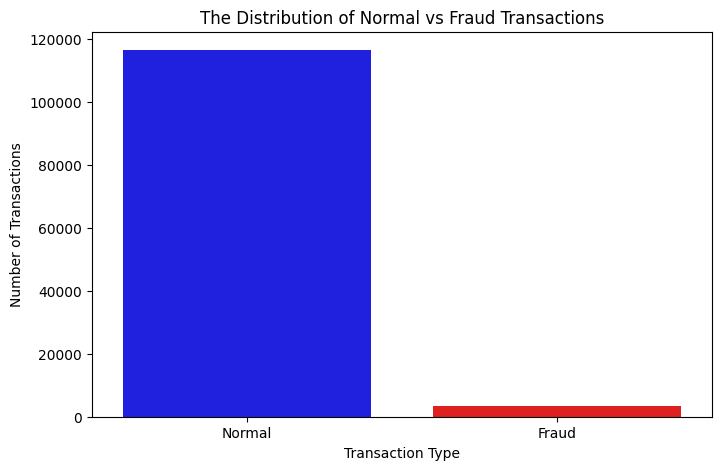

In [24]:
#for easier plotting, we change the 0/1 in the is_fraud column to text labels: 0 rep normal and 1 rep Fraud
eda_df['Fraud_Label'] = eda_df['is_fraud'].map({0: 'Normal', 1: 'Fraud'})

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=eda_df, x='Fraud_Label', palette=['blue', 'red'])
plt.title('The Distribution of Normal vs Fraud Transactions')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Transactions')
plt.show

Due to the severe imbalance of the normal and fraud transactions as seen , use of class_weight=balanced and ROC_AUC is necessary to ensure the models keep in mind of the 97% vs 3% of the dataset.

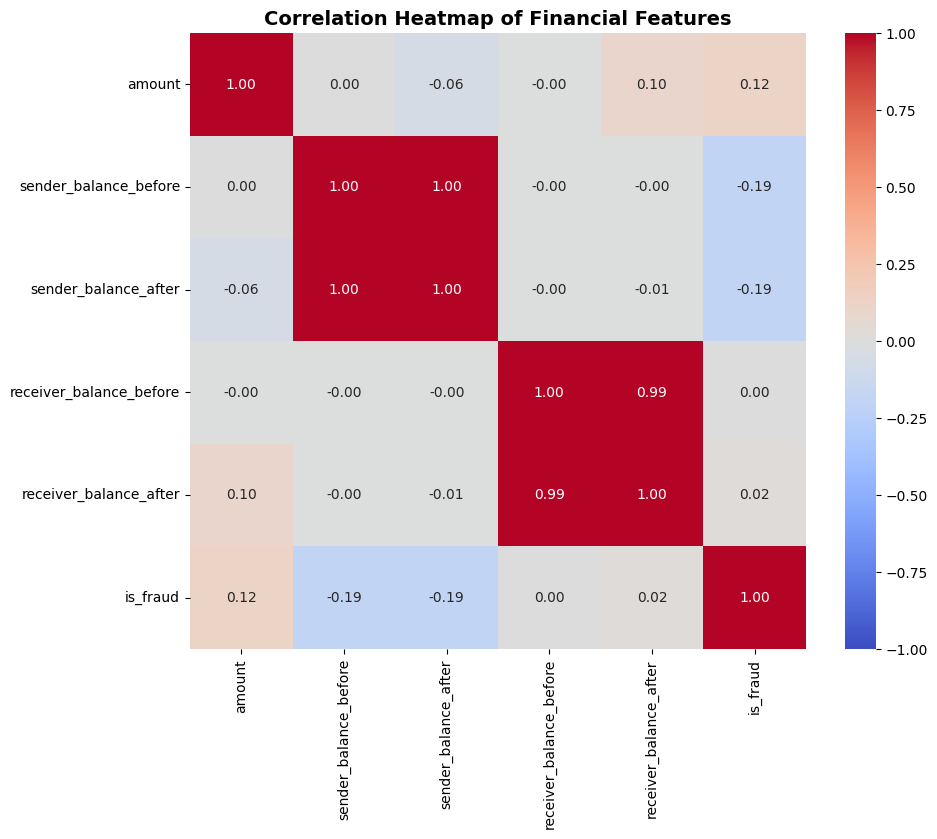

In [25]:
plt.figure(figsize=(10, 8))
numerical_df = eda_df[['amount', 'sender_balance_before', 'sender_balance_after', 'receiver_balance_before', 'receiver_balance_after', 'is_fraud']]

corr_matrix = numerical_df.corr()
#annot=True puts the actual numbers in the squares.
#uses red for strong positive correlation and blue for strong negative.
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation Heatmap of Financial Features', fontsize=14, fontweight='bold')
plt.show()

The strongest correlations with is_fraud are Sender Balance After (-0.194) and Sender Balance Before (-0.193). Because these numbers are negative, it means that as the sender's account balance goes down, the probability of the transaction being fraudulent goes up.

 Fraudsters often target accounts with lower balances or attempt to completely drain an account until it hits zero.